In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 22})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Using PCA dimensionality reduction to qualitatively estimate the classifier's performance on the unlabeled challenge's test set

## Loading the data set

In [54]:
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv').drop('id', axis=1)
train_mean, train_std = train_x.mean(), train_x.std()
train_x = (train_x - train_mean) / train_std
base_features = train_x.columns

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
valid_x = (valid_x - train_mean) / train_std
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
test_x = (test_x - train_mean) / train_std
valid_test_x = pd.concat([valid_x, test_x])

In [105]:
def plot_3d_pca(data, loadings, labels, features=base_features, scale=0.5):
    for i in range(3):
        data[f'PC{i + 1}'] = data[features].dot(loadings[i, :])

    fig = plt.figure(figsize=(20 * scale, 20 * scale))
    ax = fig.add_subplot(111, projection='3d')
    s = 0.5 * 750_000 / len(data)
    for label in [0, 1]:
        ax.scatter(
            data[labels == label]['PC1'],
            data[labels == label]['PC2'],
            data[labels == label]['PC3'],
            c={0: 'g', 1: 'r'}[label],
            label={0: 'Healthy', 1: 'Faulty'}[label], alpha=0.04, s=s
        )
    ax.view_init(elev=25, azim=180 + 55)
    plt.legend(loc="upper right")
    plt.grid(True)
    return ax

In [ ]:
pca = PCA(n_components=len(base_features))
pca.fit_transform(train_x[base_features])
train_loadings = pca.components_[:3]
plot_3d_pca(train_x, train_loadings, train_y['faulty'].values)

# BarH Loadings
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
for i in range(3):
    norm = plt.Normalize(0, max(train_loadings[i]))
    colors = plt.cm.viridis(norm(abs(train_loadings[i])))
    ax[i].barh(base_features, train_loadings[i], color=colors, alpha=0.85)
    ax[i].set_title(f'PC{i + 1}')
    ax[i].axvline(0, color='k', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## Visualizing the valid/test set distribution

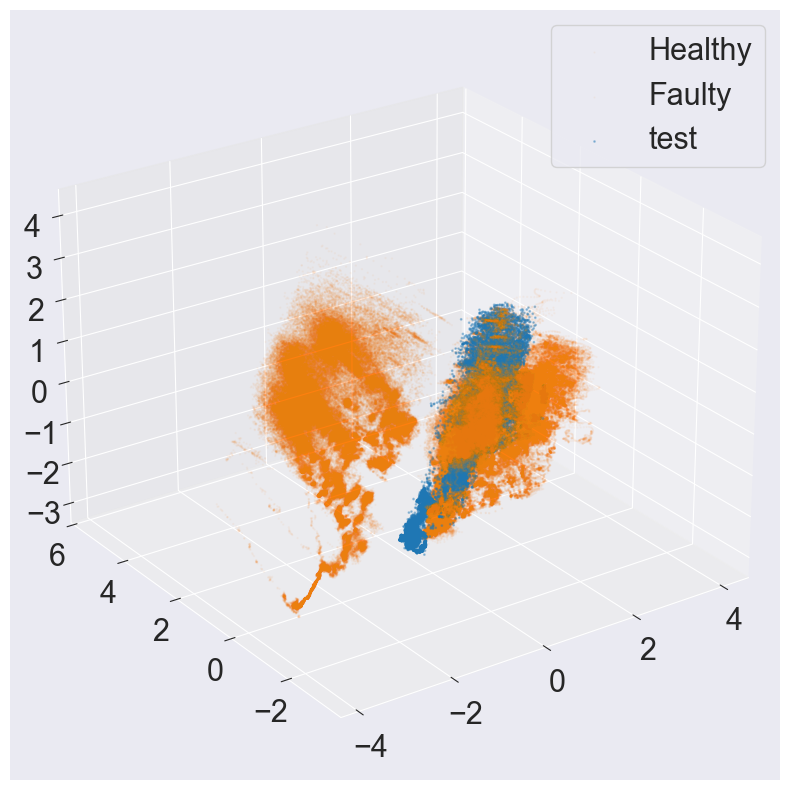

In [104]:
ax = plot_3d_pca(train_x, train_loadings, train_y['faulty'].values, scale=0.5)

for i in range(3):
    valid_test_x[f'PC{i + 1}'] = valid_test_x[base_features].dot(train_loadings[i, :])
ax.scatter(
    valid_test_x['PC1'],
    valid_test_x['PC2'],
    valid_test_x['PC3'],
    c='tab:blue', label='test', alpha=0.35, s=1
)
plt.legend(loc="upper right")
plt.show()

# Predicting the valid/test sets

## Calculating derived features

## Torque Margin estimation

## Fault Detection